In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
import seaborn as sns
import utils.base_utils as bu
import utils.window_utils as wu
import numpy as np
import matplotlib.pyplot as plt
from utils.publication_lags import apply_fred_md_publication_lag
from utils.macro_grouping import add_group_level, build_full_group_mapping, groups_as_array

repo_root = os.path.abspath('../..')

# Bianchi period:
start_date = '1971-08-31'
end_date = '2018-12-31'
# end_date = '2025-06-30' # kr and gsw end date

maturities = [str(i) for i in range(12, 121) if i % 12 == 0] # select only yearly maturities

yields = bu.get_yields(type='lw', start=start_date, end=end_date, maturities=maturities) # type can be kr, lw, gsw
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna() # horizon=12 means holding for 12 months

# adjust fred_md start_date by 6 months to fetch enough data for shifting
fred_md_start_date = pd.to_datetime(start_date) - pd.DateOffset(months=6)
fred_md_raw = bu.get_fred_data('data/2026-01-MD.csv', start=fred_md_start_date, end=end_date) # this is aligned to the last day of the previous month, so we get the same number of observations as the yields data

monthly_yields = bu.get_yields(type='lw', start=start_date, end=end_date, maturities=[str(i) for i in range(1, 121)]) # needed for monthly holding period excess returns. Not available for gsw
monthly_xr = bu.get_excess_returns(monthly_yields, horizon=1).dropna() # calculate monthly excess returns for robustness

# If wanted, apply per-series publication lag to latest-snapshot macro data
# from utils.publication_lags import apply_fred_md_publication_lag
# fred_md = apply_fred_md_publication_lag(fred_md_raw)  
# For results in paper, we naively shift all FRED-MD series by 1 month
# to reflect publication lag:
fred_md = fred_md_raw.shift(1)

# Drop TWEXAFEGSMTHx and ACOGNO as they start late
fred_md = fred_md.drop(columns=['TWEXAFEGSMTHx', 'ACOGNO'])
# Finally, revert fred_md to start_date, after transformations and lag adjustments
fred_md = fred_md[start_date:end_date]

# Drop dates outside the xr range
yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]
monthly_xr = monthly_xr.loc[monthly_xr.index <= xr.index[-1]]

# Construct X with 3-level MultiIndex: (source, group, series)
s2g = build_full_group_mapping(fred_md, forward, yields)

X = pd.concat([fred_md, forward, yields],
               axis=1,
               keys=['fred', 'forward', 'yields'])

X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')
# For now, forward fill X
X = X.ffill()

groups = groups_as_array(X, level='group')

y_all = xr[['24','36','48','60','72','84','96','108','120']].values
dates = xr.index

/home/ulrikts/Documents/NTNU/TIO4900-Replication/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:219: UserWarning: The following series are defined in get_fredmd_grouping() but are not present in the FRED-MD data: ['ACOGNO', 'TWEXAFEGSMTHx']. They may have been dropped or renamed.
  warnings.warn(
/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:168: UserWarning: 2 entries in series_to_group are not present in the DataFrame columns: ['ACOGNO', 'TWEXAFEGSMTHx']
  warnings.warn(


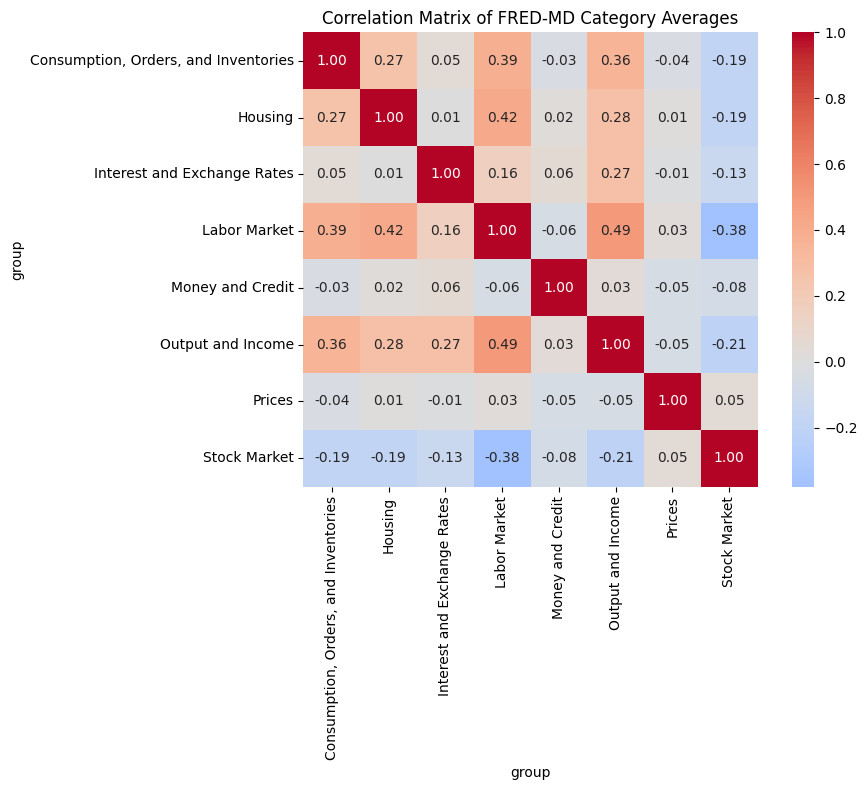

In [4]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Standard scale all columns of X['fred']
scaler = StandardScaler()
x_fred_scaled = pd.DataFrame(
    scaler.fit_transform(X['fred']), 
    index=X['fred'].index, 
    columns=X['fred'].columns
)

# 2. Average across the multiindex category (level 0)
category_averages = x_fred_scaled.T.groupby(level=0).mean().T

# 3. Plot the correlation matrix across the macro categories
plt.figure(figsize=(10, 8))
corr_matrix = category_averages.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, square=True)
plt.title('Correlation Matrix of FRED-MD Category Averages')
plt.tight_layout()
plt.show()